# 4. Detection of Local Extrema

Objective: To identify the local extrema of motion signals
while ignoring micro-oscillations caused by MediaPipe noise.

These extrema will then be used to calculate:
- **QoM** = total number of local extrema

Method:
1. Identify a motionless segment from the video
   to measure the standard deviation of the residual noise.
2. Define an amplitude threshold = `k × σ_noise` where k ∈ {2, 3}.
3. Extremes are detected by **a change in the sign of the derivative**
   of the signal, and are only retained if the amplitude between them
   exceeds the threshold.

## 4.1 Imports et configuration

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd().parent.parent

from config import (
    DATA_DIR, ID_COLS, MOVEMENT_SIGNALS, FPS,
)

print(f"FPS : {FPS}")
print(f"Mouvements ({len(MOVEMENT_SIGNALS)}) : {MOVEMENT_SIGNALS}")

FPS : 30.0
Mouvements (6) : ['left_hand_vertical', 'right_hand_vertical', 'left_hand_horizontal', 'right_hand_horizontal', 'head_horizontal', 'head_vertical']


## 4.2 Loading Normalized Movements

Input: `data/movement/03_normalized_signals.csv`, generated
by Notebook 3.

In [2]:
in_path = DATA_DIR / "movement" / "03_normalized_signals.csv"
df_movements = pd.read_csv(in_path)

print(f"Loaded {in_path}")
print(f"Shape : {df_movements.shape}")
print(f"Participants : {df_movements['participant_id'].nunique()}")
display(df_movements.head())

Loaded C:\Users\factory\Desktop\pons.lea\data\movement\03_normalized_signals.csv
Shape : (36238, 9)
Participants : 40


,group,participant_id,frame,left_hand_vertical,right_hand_vertical,left_hand_horizontal,right_hand_horizontal,head_horizontal,head_vertical
0,P,P1,0,-2.299396,-2.416387,-0.335999,0.124346,0.001669,1.043054
1,P,P1,1,-2.303771,-2.413923,-0.339779,0.121162,0.005145,1.049179
2,P,P1,2,-2.307631,-2.411848,-0.348793,0.113427,0.007991,1.052101
3,P,P1,3,-2.309234,-2.409766,-0.359783,0.103488,0.010848,1.054328
4,P,P1,4,-2.307629,-2.407424,-0.370330,0.093210,0.014077,1.057547


# 4.3 Calibrating the Threshold on a Stationary Segment

**Method** :  
Identify a
time window during which the participant is not moving (based on
observation of the video). Everything measured during this window is, by
definition, noise. The **standard deviation of the signal over this segment**
directly gives the typical size of the noise, in units of the signal.

The amplitude threshold for detecting extrema is then
`k × σ`, where k = 2 or 3. This is the standard multiplier: when
k = 3, approximately 99.7% of the Gaussian noise falls below this threshold, so
anything above it is almost certainly the true signal.

**Choosing the global threshold.** Since all movements are
normalized by the width of the shoulders (notebook 3), they are
all in the same unit. A single threshold is sufficient for all 8 signals.

### 4.3.1 Selecting the Stationary Segment

A video segment in which the participant appeared visually motionless was manually selected. This segment was then used to check the amount of variation present in the motion signals when no actual movement was expected.

In [3]:
CALIB_PARTICIPANT_ID = "P19"
CALIB_FRAMES = (0, 300)  
CALIB_mvt = "left_hand_vertical"  
# =================

f_start, f_end = CALIB_FRAMES

calib_mask = (
    (df_movements["participant_id"] == CALIB_PARTICIPANT_ID)
    & (df_movements["frame"] >= f_start)
    & (df_movements["frame"] <= f_end)
)

calib_segment = df_movements.loc[calib_mask].copy()

if calib_segment.empty:
    raise ValueError(
        f"Segment vide pour {CALIB_PARTICIPANT_ID} "
        f"frames {CALIB_FRAMES}"
    )

if CALIB_mvt not in df_movements.columns:
    raise ValueError(f"{CALIB_mvt} do not exist in df_movements")

print(f"Participant : {CALIB_PARTICIPANT_ID}")
print(f"Frames      : {f_start}-{f_end} ({len(calib_segment)} pts)")
print(f"Mouvement      : {CALIB_mvt}")

Participant : P19
Frames      : 0-300 (301 pts)
Mouvement      : left_hand_vertical


### 4.3.2 Visual Inspection

The signal must be nearly flat.

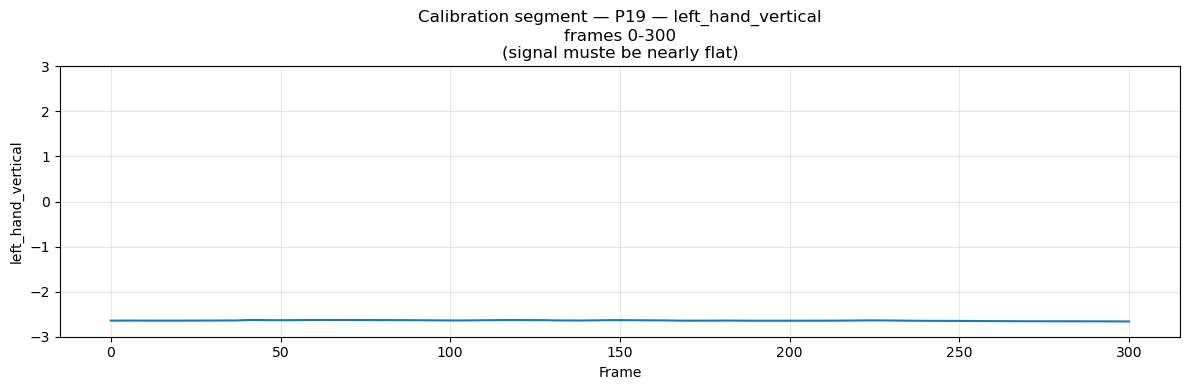

In [4]:
plt.figure(figsize=(12, 4))

plt.plot(
    calib_segment["frame"],
    calib_segment[CALIB_mvt]
)

plt.title(
    f"Calibration segment — {CALIB_PARTICIPANT_ID} — {CALIB_mvt}\n"
    f"frames {f_start}-{f_end}\n"
    "(signal muste be nearly flat)"
)

plt.ylim(-3,3)
plt.xlabel("Frame")
plt.ylabel(CALIB_mvt)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3.3 Calculating the Threshold

We calculate the standard deviation across all concatenated signals from the
stationary segment: this provides an overall, stable estimate
of the noise, independent of the choice of any particular signal.

Each signal has its own mean level, so we **center** them
(subtract the mean) before concatenation to measure
only the dispersion.

In [5]:
all_values = []
for sig_col in MOVEMENT_SIGNALS:
    v = calib_segment[sig_col].dropna().to_numpy()
    all_values.append(v - v.mean())
all_values = np.concatenate(all_values)

sigma_noise = all_values.std(ddof=1)

# We keep k=3 as default 
K = 3.0
AMPLITUDE_THRESHOLD = K * sigma_noise

print(f"σ_noise             : {sigma_noise:.6f}")
print(f"k                    : {K}")
print(f"Amplitude threshold    : {AMPLITUDE_THRESHOLD:.6f}")

σ_noise             : 0.017041
k                    : 3.0
Amplitude threshold    : 0.051124


## 4.4 Detecting Extremes

1. Compute the derivative of the signal (centered finite differences).
2. Mark a candidate extremum at each sign change of
   the derivative (`v[t-1]` and `v[t+1]` have opposite signs).
3. Filter: iterate through the candidates in order and
   accept a new candidate only if
   `|signal[candidate] - signal[last_accepted]| ≥ threshold`.

The derivative is used only to **locate** the candidates:
the final filtering is performed on the amplitude of the signal itself,
compared to the calibrated threshold.

In [6]:
def detect_extrema(signal, amplitude_threshold, fps=FPS):
    """
    Detects local extrema in a signal.

    Parameters
    ----------
    signal: np.ndarray
        1D signal (may contain NaNs).
    amplitude_threshold: float
        Minimum amplitude (in signal units) between successive extrema
        to be considered.
    fps: float
        To calculate the derivative in units per second.

    Returns
    -------
    indices: np.ndarray
        Positions of the selected extrema.
    types: np.ndarray
        ‘max’ or ‘min’ for each extremum.
    """
    signal = np.asarray(signal, dtype=float)
    n = len(signal)
    if n < 3:
        return np.array([], dtype=int), np.array([], dtype=object)

    # 1. Derived using centered finite differences.
    deriv = np.gradient(signal, 1.0 / fps)

    # 2. Candidates: Changes in the sign of the derivative.
    candidates = []
    for t in range(1, n - 1):
        v_prev, v_next = deriv[t - 1], deriv[t + 1]
        if np.isnan(v_prev) or np.isnan(v_next) or np.isnan(signal[t]):
            continue
        if v_prev > 0 and v_next < 0:
            candidates.append((t, "max"))
        elif v_prev < 0 and v_next > 0:
            candidates.append((t, "min"))

    if not candidates:
        return np.array([], dtype=int), np.array([], dtype=object)

    # 3. Amplitude-threshold filtering.
    accepted = [candidates[0]]
    for t, kind in candidates[1:]:
        last_t, _ = accepted[-1]
        if abs(signal[t] - signal[last_t]) >= amplitude_threshold:
            accepted.append((t, kind))

    indices = np.array([t for t, _ in accepted], dtype=int)
    types = np.array([k for _, k in accepted], dtype=object)
    return indices, types


print("Function detect_extrema ready.")

Function detect_extrema ready.


## 4.5 Visual Inspection

The algorithm is applied to a participant, and the detected extrema
are plotted on the four signals. Red triangles = maxima, blue triangles = minima.

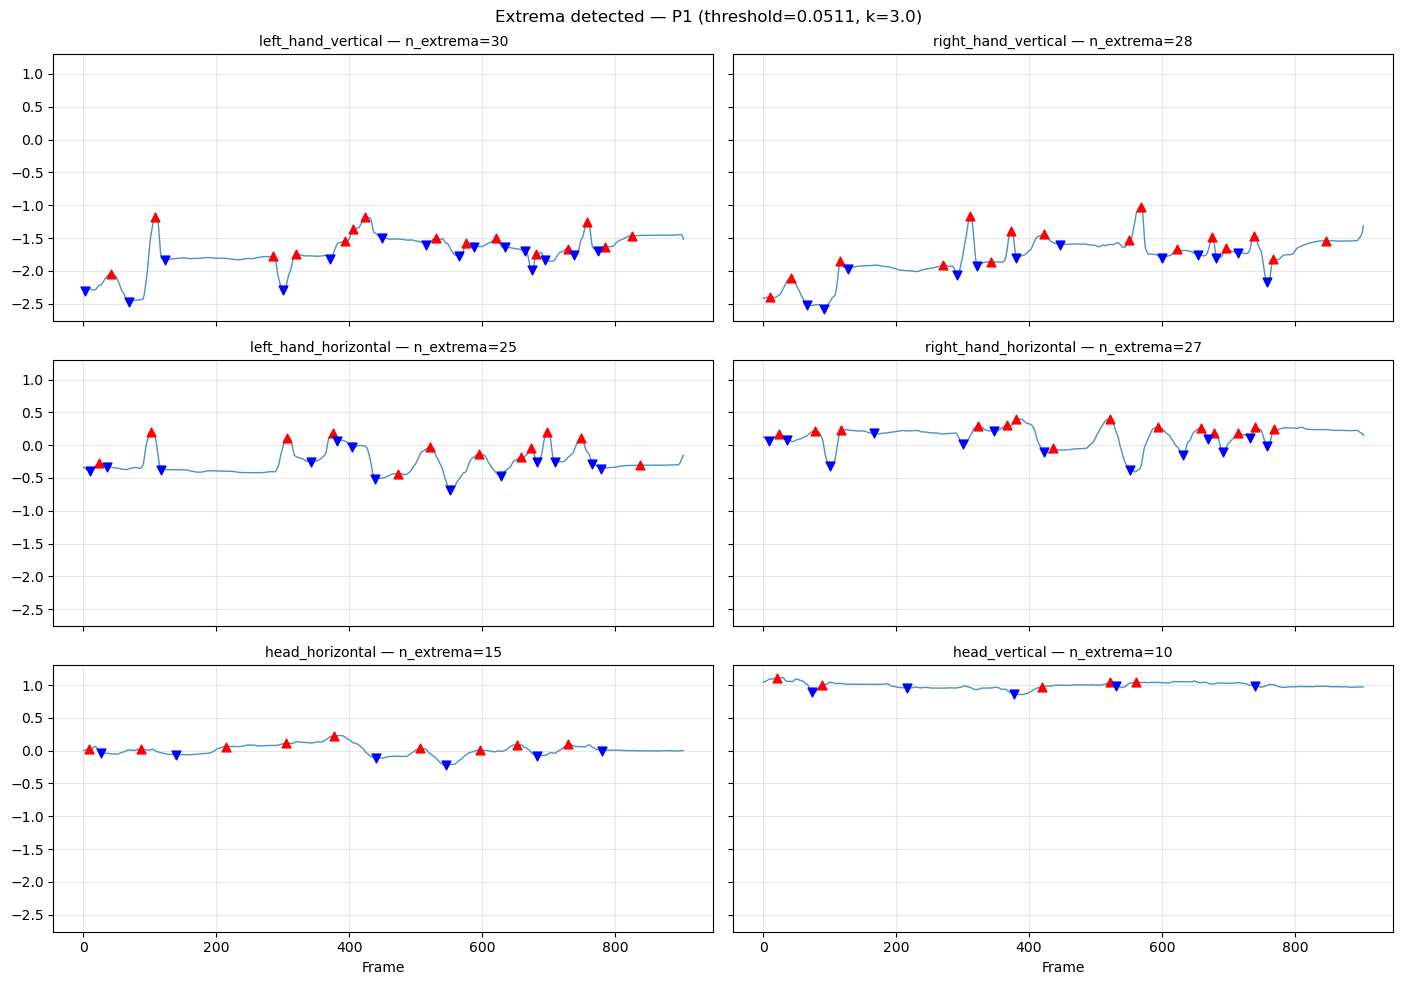

In [7]:
def plot_extrema(df, participant_id, signal_col,
                 amplitude_threshold, ax=None):
    """Plot the signal with the detected extrema superimposed on it."""
    sub = df[df["participant_id"] == participant_id].sort_values("frame")
    sig = sub[signal_col].to_numpy()
    frames = sub["frame"].to_numpy()

    idx, types = detect_extrema(sig, amplitude_threshold)

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 3))
    ax.plot(frames, sig, lw=1.0, alpha=0.8)
    if len(idx):
        is_max = types == "max"
        ax.scatter(frames[idx[is_max]], sig[idx[is_max]],
                   color="red", marker="^", s=40, zorder=3)
        ax.scatter(frames[idx[~is_max]], sig[idx[~is_max]],
                   color="blue", marker="v", s=40, zorder=3)
    ax.set_title(f"{signal_col} — n_extrema={len(idx)}", fontsize=10)
    ax.grid(True, alpha=0.3)
    return idx, types


TEST_PID = "P1" 

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey=True)
for ax, sig_col in zip(axes.flat, MOVEMENT_SIGNALS):
    plot_extrema(df_movements, TEST_PID, sig_col,
                 AMPLITUDE_THRESHOLD, ax=ax)
axes[-1, 0].set_xlabel("Frame")
axes[-1, 1].set_xlabel("Frame")
fig.suptitle(
    f"Extrema detected — {TEST_PID} "
    f"(threshold={AMPLITUDE_THRESHOLD:.4f}, k={K})"
)
plt.tight_layout()
plt.show()

## 4.6 Sensitivity to the Choice of k

We test k ∈ {1, 2, 3, 5} to verify that the choice is not
critical. Ideally, the number of detected extrema does not change
drastically between k=2 and k=3 (= stability region).

Number of local extrema per signal according to k :


signal,head_horizontal,head_vertical,left_hand_horizontal,left_hand_vertical,right_hand_horizontal,right_hand_vertical
k,,,,,,
1,23.3,32.3,27.8,33.4,27.8,32.6
2,14.2,19.2,19.6,22.7,19.9,22.0
3,9.5,13.6,16.1,17.3,14.8,16.2
5,6.0,8.0,11.7,12.5,10.4,11.8


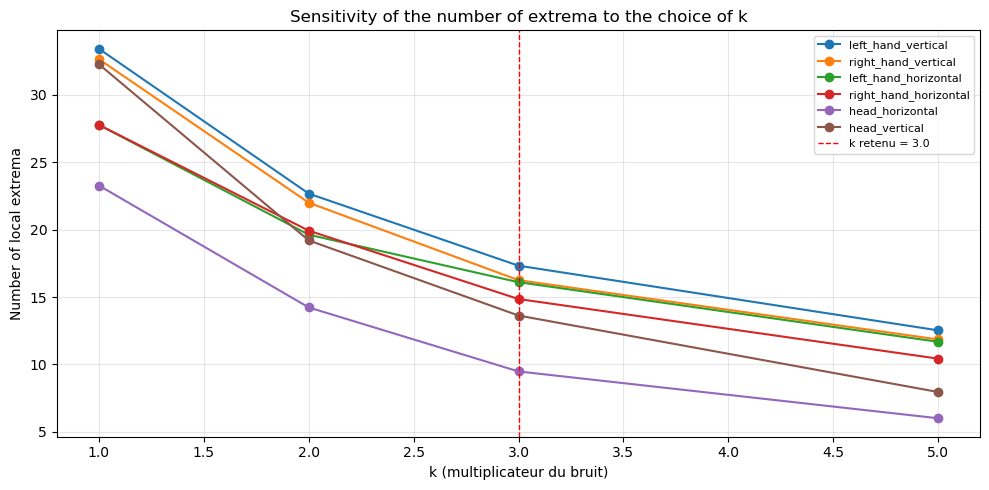

In [8]:
def count_extrema(df, signal_col, amplitude_threshold):
    """Number of local extrema per participant for a given signal."""
    counts = []
    for pid, sub in df.groupby("participant_id", sort=False):
        sub = sub.sort_values("frame")
        sig = sub[signal_col].to_numpy()
        idx, _ = detect_extrema(sig, amplitude_threshold)
        counts.append(len(idx))
    return np.mean(counts)


k_values = [1, 2, 3, 5]
rows = []
for k in k_values:
    thr = k * sigma_noise
    for sig_col in MOVEMENT_SIGNALS:
        rows.append({
            "k": k,
            "signal": sig_col,
            "mean_n_extrema": count_extrema(df_movements, sig_col, thr),
        })

sensitivity = pd.DataFrame(rows)
pivot = sensitivity.pivot(index="k", columns="signal",
                          values="mean_n_extrema")

print("Number of local extrema per signal according to k :")
display(pivot.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
for sig_col in MOVEMENT_SIGNALS:
    ax.plot(pivot.index, pivot[sig_col], marker="o", label=sig_col)
ax.axvline(K, color="red", ls="--", lw=1, label=f"k retenu = {K}")
ax.set_xlabel("k (multiplicateur du bruit)")
ax.set_ylabel("Number of local extrema")
ax.set_title("Sensitivity of the number of extrema to the choice of k")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.7 Applying to All Signals and Saving

Output: 
**data/movement/04_extrema.csv** a long dataframe with one row per extremum, ready for
calculating QoM in a later notebook.

In [9]:
def detect_all_extrema(df, signal_cols, amplitude_threshold):
    """Detect all extrema for all (participant, signal) pairs."""
    pid_to_group = (
        df.drop_duplicates("participant_id")
        .set_index("participant_id")["group"]
    )
    rows = []
    for pid, sub in df.groupby("participant_id", sort=False):
        sub = sub.sort_values("frame")
        frames = sub["frame"].to_numpy()
        for sig_col in signal_cols:
            sig = sub[sig_col].to_numpy()
            idx, types = detect_extrema(sig, amplitude_threshold)
            for i, t in zip(idx, types):
                rows.append({
                    "group": pid_to_group[pid],
                    "participant_id": pid,
                    "signal": sig_col,
                    "frame": int(frames[i]),
                    "type": t,
                    "value": float(sig[i]),
                })
    return pd.DataFrame(rows)


df_extrema = detect_all_extrema(
    df_movements, MOVEMENT_SIGNALS, AMPLITUDE_THRESHOLD,
)

print(f"Total extrema detected : {len(df_extrema)}")
print("\nPer signal :")
display(df_extrema.groupby("signal").size().rename("n_extrema"))
print("\nPer participant :")
display(
    df_extrema.groupby(["participant_id", "signal"])
    .size().unstack(fill_value=0)
)

Total extrema detected : 3505

Per signal :


signal
head_horizontal          379
head_vertical            545
left_hand_horizontal     644
left_hand_vertical       693
right_hand_horizontal    594
right_hand_vertical      650
Name: n_extrema, dtype: int64


Per participant :


signal,head_horizontal,head_vertical,left_hand_horizontal,left_hand_vertical,right_hand_horizontal,right_hand_vertical
participant_id,,,,,,
P1,15,10,25,30,27,28
P10,11,19,21,24,24,25
P11,23,15,10,23,13,3
P12,15,13,34,39,29,37
P13,3,6,6,11,4,6
P14,6,12,31,26,20,16
P15,15,13,7,10,8,2
P16,15,24,37,26,31,28
P17,3,1,1,2,1,1


In [10]:
out_path = DATA_DIR / "movement" / "04_extrema.csv"
df_extrema.to_csv(out_path, index=False)

print(f"Saved extrema -> {out_path}")
display(df_extrema.head(10))

Saved extrema -> C:\Users\factory\Desktop\pons.lea\data\movement\04_extrema.csv


,group,participant_id,signal,frame,type,value
0,P,P1,left_hand_vertical,2,min,-2.307631
1,P,P1,left_hand_vertical,41,max,-2.047892
2,P,P1,left_hand_vertical,69,min,-2.470514
3,P,P1,left_hand_vertical,108,max,-1.175648
4,P,P1,left_hand_vertical,122,min,-1.828153
5,P,P1,left_hand_vertical,286,max,-1.775456
6,P,P1,left_hand_vertical,300,min,-2.284688
7,P,P1,left_hand_vertical,320,max,-1.735445
8,P,P1,left_hand_vertical,371,min,-1.819391
9,P,P1,left_hand_vertical,394,max,-1.549315
